# Chapter 2 — Data and Sampling Distributions
### Reproduction & Theoretical Deep-Dive — *Practical Statistics for Data Scientists*

Chapter 1 was about describing the data we already have. Chapter 2 is about
a deeper question: **how much can we trust a statistic computed from a
sample to represent the whole population?**

**Chapter roadmap:**
1. Sampling Distribution of a Statistic
2. The Bootstrap
3. Confidence Intervals
4. Normal Distribution
5. Long-Tailed Distributions
6. Binomial Distribution
7. Poisson and Related Distributions (Exponential, Weibull)


In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pylab as plt
import seaborn as sns

sns.set_style('whitegrid')
rng = np.random.default_rng(42)

DATA = Path('data')
LOANS_INCOME_CSV = DATA / 'loans_income.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'


## 1. Sampling Distribution of a Statistic

**Theory.** A *sample* is a subset drawn from a *population*. A **sampling
distribution** is the distribution you'd get if you repeated "draw a sample,
compute a statistic (e.g. the mean)" many, many times. Its key properties:
- The sampling distribution of the mean is **narrower** than the
  distribution of the individual data points — averaging cancels out some of
  the noise.
- As sample size *n* grows, the sampling distribution gets narrower and more
  bell-shaped, even if the original data isn't normal — this is the
  **Central Limit Theorem (CLT)**.
- Don't confuse this with the *data distribution* (the raw values) — they
  answer different questions: "what does one observation look like?" vs.
  "how much does a sample statistic vary across different samples?"

We illustrate this with `loans_income.csv` (individual loan applicants'
annual income).


In [2]:
loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')
print(f"Number of individual incomes: {len(loans_income):,}")
loans_income.describe()


Number of individual incomes: 50,000


count     50000.00000
mean      68760.51844
std       32872.03537
min        4000.00000
25%       45000.00000
50%       62000.00000
75%       85000.00000
max      199000.00000
Name: x, dtype: float64

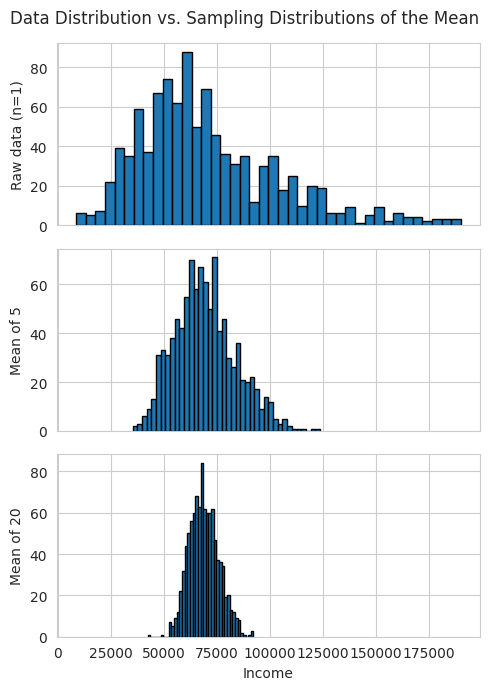

In [3]:
# Build three distributions:
# 1) the raw data itself
# 2) the distribution of means of samples of size 5
# 3) the distribution of means of samples of size 20
n_draws = 1000

raw_sample = pd.DataFrame({'income': loans_income.sample(n_draws, random_state=1), 'type': 'Raw data (n=1)'})

means_n5 = pd.DataFrame({
    'income': [loans_income.sample(5, random_state=i).mean() for i in range(n_draws)],
    'type': 'Mean of 5',
})

means_n20 = pd.DataFrame({
    'income': [loans_income.sample(20, random_state=i).mean() for i in range(n_draws)],
    'type': 'Mean of 20',
})

results = pd.concat([raw_sample, means_n5, means_n20])

fig, axes = plt.subplots(nrows=3, figsize=(5, 7), sharex=True)
for ax, (label, group) in zip(axes, results.groupby('type', sort=False)):
    group['income'].plot.hist(ax=ax, bins=40, edgecolor='black')
    ax.set_ylabel(label)
axes[-1].set_xlabel('Income')
fig.suptitle('Data Distribution vs. Sampling Distributions of the Mean')
plt.tight_layout()
plt.savefig('outputs/sampling_distribution_means.png', dpi=110)
plt.show()


**Reading the output.** The raw income data is right-skewed with a long
tail of high earners. As we move to means of 5, then means of 20, the
distributions become progressively narrower and more symmetric/bell-shaped —
exactly what the Central Limit Theorem predicts. This is *why* the mean is
such a useful statistic: its sampling distribution behaves predictably
regardless of the shape of the underlying data.


## 2. The Bootstrap

**Theory.** In real life we usually only have **one** sample, not the luxury
of drawing 1,000 fresh samples from the population like above. The
**bootstrap** simulates that by resampling *with replacement* from the one
sample we do have, as if it were the population. Repeating this thousands of
times and recomputing the statistic each time approximates the statistic's
sampling distribution — without needing more data collection or complex
probability formulas. It's a purely computational alternative to formula-
based statistical theory.


In [4]:
def bootstrap_statistic(data, stat_fn, n_boot=2000, seed=1):
    rng_local = np.random.default_rng(seed)
    n = len(data)
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        resample = rng_local.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(resample)
    return boot_stats

one_sample = loans_income.sample(1000, random_state=1).to_numpy()
boot_means = bootstrap_statistic(one_sample, np.mean, n_boot=2000)

print(f"Original sample mean:        {one_sample.mean():,.0f}")
print(f"Bootstrap mean of the means:  {boot_means.mean():,.0f}")
print(f"Bootstrap standard error:     {boot_means.std():,.0f}")


Original sample mean:        70,567
Bootstrap mean of the means:  70,567
Bootstrap standard error:     1,051


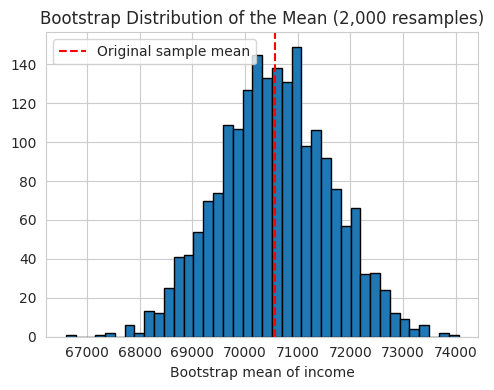

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(boot_means, bins=40, edgecolor='black')
ax.axvline(one_sample.mean(), color='red', linestyle='--', label='Original sample mean')
ax.set_xlabel('Bootstrap mean of income')
ax.set_title('Bootstrap Distribution of the Mean (2,000 resamples)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/bootstrap_distribution.png', dpi=110)
plt.show()


**Reading the output.** The bootstrap standard error (the spread of the
bootstrap means) approximates how much a sample mean of this size would
naturally vary from sample to sample — without ever touching the true
population. This is the bootstrap's core value: an empirical, formula-free
way to quantify a statistic's uncertainty.


## 3. Confidence Intervals

**Theory.** A **confidence interval (CI)** gives a range of plausible values
for a population parameter, built so that if we repeated the whole sampling-
and-interval-building process many times, roughly *X%* of the resulting
intervals would contain the true value. A 90% CI is **narrower** than a 95%
CI, which is narrower than a 99% CI — more confidence requires a wider net.
The bootstrap gives us a simple way to build a CI: just take the appropriate
percentiles of the bootstrap distribution (the **percentile method**).


In [6]:
def bootstrap_ci(boot_stats, conf_level=0.90):
    alpha = 1 - conf_level
    lower = np.percentile(boot_stats, 100 * alpha / 2)
    upper = np.percentile(boot_stats, 100 * (1 - alpha / 2))
    return lower, upper

for conf in [0.90, 0.95, 0.99]:
    lo, hi = bootstrap_ci(boot_means, conf)
    print(f"{int(conf*100)}% CI for mean income: [{lo:,.0f}, {hi:,.0f}]  (width: {hi-lo:,.0f})")


90% CI for mean income: [68,820, 72,334]  (width: 3,514)
95% CI for mean income: [68,551, 72,605]  (width: 4,054)
99% CI for mean income: [67,999, 73,300]  (width: 5,301)


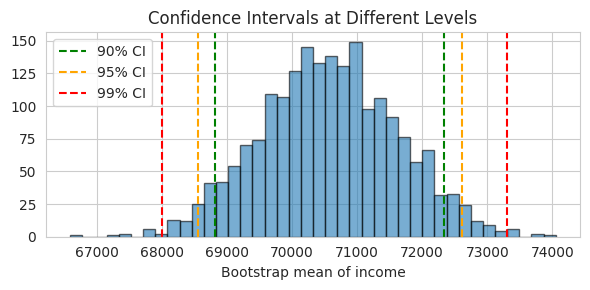

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(boot_means, bins=40, edgecolor='black', alpha=0.6)
for conf, color in zip([0.90, 0.95, 0.99], ['green', 'orange', 'red']):
    lo, hi = bootstrap_ci(boot_means, conf)
    ax.axvline(lo, color=color, linestyle='--', label=f'{int(conf*100)}% CI')
    ax.axvline(hi, color=color, linestyle='--')
ax.set_xlabel('Bootstrap mean of income')
ax.set_title('Confidence Intervals at Different Levels')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/confidence_intervals.png', dpi=110)
plt.show()


**Reading the output.** The 99% CI is visibly wider than the 90% CI —
being more confident that the interval captures the true mean requires
casting a wider net. This trade-off (confidence level vs. interval width) is
fundamental: a CI is only useful if it's narrow enough to be informative.


## 4. Normal Distribution

**Theory.** The **normal (Gaussian) distribution** is the classic
bell-shaped curve, defined entirely by its mean (center) and standard
deviation (spread). It's important less because raw data is "usually
normal" (it often isn't — see the long-tailed section below) and more
because of the **Central Limit Theorem**: sums/means of many independent
variables tend toward a normal distribution regardless of the original
shape, as we saw in Section 1. A **QQ-plot** (quantile-quantile plot) is the
standard diagnostic tool: it plots a dataset's quantiles against the
quantiles of a theoretical normal distribution — if the data is normal, the
points fall on a straight diagonal line.


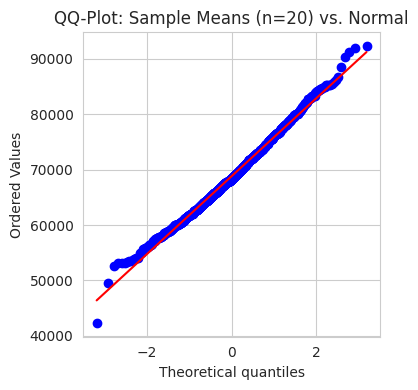

In [8]:
# Compare our n=20 sample-mean distribution from Section 1 (should look
# close to normal thanks to the CLT) against a QQ-plot.
fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(means_n20['income'], dist='norm', plot=ax)
ax.set_title('QQ-Plot: Sample Means (n=20) vs. Normal')
plt.tight_layout()
plt.savefig('outputs/qqplot_normal.png', dpi=110)
plt.show()


**Reading the output.** The points mostly hug the diagonal red line,
confirming the sample-mean distribution is close to normal — a direct,
visual confirmation of the Central Limit Theorem in action for this dataset.


## 5. Long-Tailed Distributions

**Theory.** Not all real-world data is normal. Many datasets — income,
stock returns, city populations, word frequencies — have **long (heavy)
tails**: extreme values occur far more often than a normal distribution
would predict. Assuming normality for long-tailed data is a common and
costly mistake, especially in finance (it leads to underestimating the
probability of extreme/crash events). A QQ-plot immediately reveals this: a
long-tailed dataset's points curve sharply away from the diagonal at the
ends.


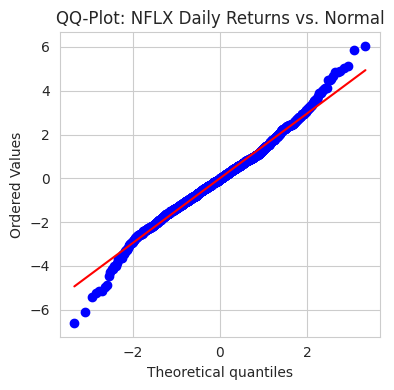

In [9]:
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)
nflx = sp500_px['NFLX']
nflx_returns = np.diff(np.log(nflx[nflx > 0]))  # daily log returns

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx_returns, dist='norm', plot=ax)
ax.set_title('QQ-Plot: NFLX Daily Returns vs. Normal')
plt.tight_layout()
plt.savefig('outputs/qqplot_longtail.png', dpi=110)
plt.show()


**Reading the output.** Unlike the sample-means QQ-plot above, this one
curves noticeably away from the diagonal at both ends — evidence of a
long-tailed distribution. In plain terms: extreme up/down days in NFLX
stock happen more often than a normal-distribution model would suggest,
which is exactly why risk models that assume normality tend to
underestimate crash risk.


## 6. Binomial Distribution

**Theory.** The **binomial distribution** models the number of "successes"
in *n* independent yes/no trials, each with the same success probability
*p* (e.g., number of heads in 20 coin flips, or number of defective items
in a batch of 100). Key parameters: *n* (number of trials) and *p*
(probability of success per trial). It's the natural distribution for any
"how many out of n" counting question with independent binary outcomes.


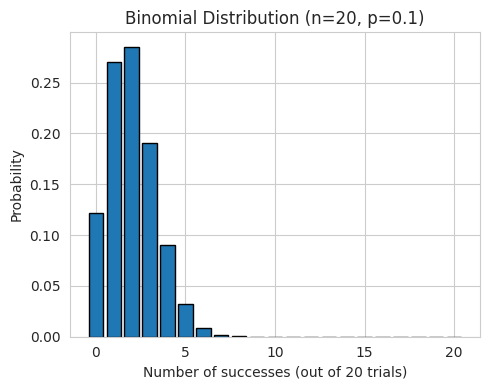

P(exactly 3 successes) = 0.190
P(3 or fewer successes) = 0.867


In [10]:
n_trials, p_success = 20, 0.1  # e.g. 20 sales calls, 10% conversion rate each

x = np.arange(0, n_trials + 1)
pmf = stats.binom.pmf(x, n_trials, p_success)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x, pmf, edgecolor='black')
ax.set_xlabel('Number of successes (out of 20 trials)')
ax.set_ylabel('Probability')
ax.set_title(f'Binomial Distribution (n={n_trials}, p={p_success})')
plt.tight_layout()
plt.savefig('outputs/binomial_distribution.png', dpi=110)
plt.show()

print(f"P(exactly 3 successes) = {stats.binom.pmf(3, n_trials, p_success):.3f}")
print(f"P(3 or fewer successes) = {stats.binom.cdf(3, n_trials, p_success):.3f}")


**Reading the output.** The distribution peaks around 2 successes
(≈ n×p = 20×0.1) and decays on both sides — most of the probability mass
sits near the expected value, with a long-ish right tail since more than 10
successes out of 20 at a 10% rate is very unlikely but not impossible.


## 7. Poisson and Related Distributions

**Theory.** The **Poisson distribution** models the number of events
occurring in a fixed interval of time or space, given a known average rate
(λ, "lambda") and assuming events occur independently (e.g., number of
customer support tickets per hour, number of website crashes per day). It's
the limiting case of the binomial distribution when *n* is large and *p* is
small but *n×p* stays constant.

Two related distributions describe the *gaps* between such events:
- **Exponential distribution** — models the *time between* Poisson events
  (e.g., time until the next customer arrives). It's memoryless: the
  probability of waiting X more minutes doesn't depend on how long you've
  already waited.
- **Weibull distribution** — a more flexible generalization of the
  exponential, with a shape parameter that lets the "failure rate" increase
  or decrease over time (unlike the exponential's constant rate). Widely
  used in reliability engineering to model time-to-failure of equipment,
  since real machines tend to wear out (increasing failure rate) rather than
  fail at a constant rate.


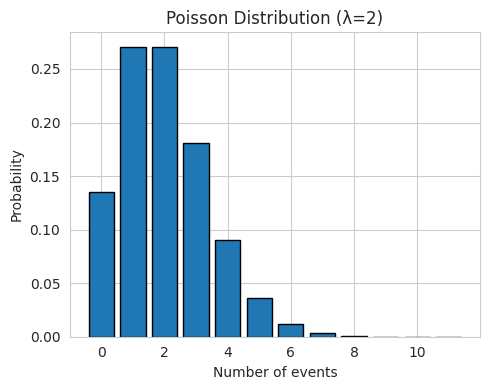

In [11]:
lam = 2  # average of 2 events per interval

x = np.arange(0, 12)
pmf_poisson = stats.poisson.pmf(x, lam)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x, pmf_poisson, edgecolor='black')
ax.set_xlabel('Number of events')
ax.set_ylabel('Probability')
ax.set_title(f'Poisson Distribution (λ={lam})')
plt.tight_layout()
plt.savefig('outputs/poisson_distribution.png', dpi=110)
plt.show()


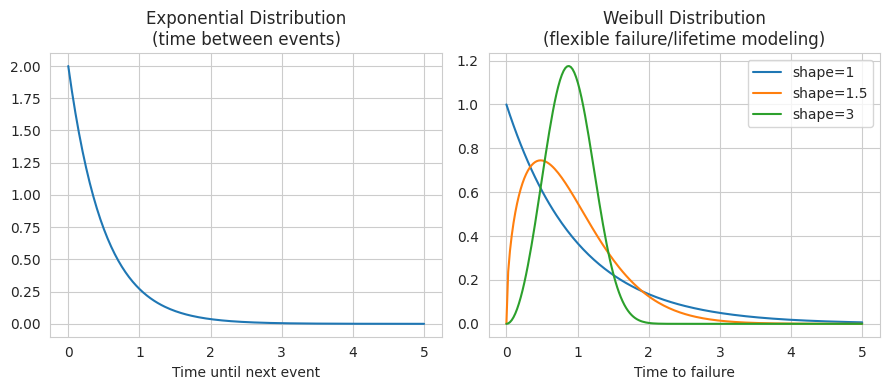

In [12]:
fig, axes = plt.subplots(ncols=2, figsize=(9, 4))

# Exponential: time between events, given the same rate lambda
x_exp = np.linspace(0, 5, 200)
axes[0].plot(x_exp, stats.expon.pdf(x_exp, scale=1/lam))
axes[0].set_title('Exponential Distribution\n(time between events)')
axes[0].set_xlabel('Time until next event')

# Weibull: shape=1 reduces to exponential (constant failure rate);
# shape > 1 models an increasing failure rate (wear-out), a common
# pattern for mechanical equipment.
x_w = np.linspace(0, 5, 200)
for shape in [1, 1.5, 3]:
    axes[1].plot(x_w, stats.weibull_min.pdf(x_w, shape), label=f'shape={shape}')
axes[1].set_title('Weibull Distribution\n(flexible failure/lifetime modeling)')
axes[1].set_xlabel('Time to failure')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/exponential_weibull.png', dpi=110)
plt.show()


**Reading the output.** The exponential curve drops off smoothly and
monotonically — consistent with a constant failure/event rate. The Weibull
plot shows how increasing the shape parameter shifts probability mass away
from very-early failures and toward a peak — this is what "wear-out" looks
like: a component is unlikely to fail immediately, but risk builds up over
time. This is why manufacturers use Weibull (not exponential) models for
warranty planning.


## Summary

| Concept | What it tells you | Key tool/formula |
|---|---|---|
| Sampling distribution | How a statistic (e.g. mean) varies across samples | Repeated sampling / CLT |
| Bootstrap | Estimate a statistic's uncertainty from one sample | Resampling with replacement |
| Confidence interval | Plausible range for a population parameter | Percentiles of bootstrap distribution |
| Normal distribution | Bell-shaped baseline; what CLT converges to | QQ-plot to check fit |
| Long-tailed distribution | Extreme values more common than normal predicts | QQ-plot curvature at the ends |
| Binomial distribution | Count of successes in n independent yes/no trials | `n`, `p` |
| Poisson distribution | Count of events in a fixed interval | rate `λ` |
| Exponential distribution | Time between Poisson events | constant event rate |
| Weibull distribution | Flexible time-to-failure modeling | shape parameter |

The overarching lesson of Chapter 2: **a single sample statistic is not the
full story** — resampling techniques (the sampling distribution concept and
its practical cousin, the bootstrap) let us quantify how much that statistic
would vary if we had drawn a different sample, which is the foundation for
every confidence interval and hypothesis test that follows in later
chapters.
